# Độ trễ truyền dẫn từ lãi suất chính sách sang gánh nặng trả nợ (DSR) — toàn bộ các nền kinh tế BIS

**Câu hỏi:** Sau chu kỳ tăng lãi suất 2021–2023, gánh nặng trả nợ (DSR) của khu vực tư nhân phi tài chính
phải mất bao lâu mới đạt đỉnh, và đến nay đã trở về mức bình thường của chính từng nền kinh tế chưa?
Bốn nền kinh tế gốc của đồ án — **Hàn Quốc, Thái Lan, Malaysia, Hong Kong SAR** — được đặt vào phân phối
chung của mọi nền kinh tế mà BIS công bố DSR.

**Nguồn:** BIS SDMX API v2 (`WS_DSR 1.0`, `WS_TC 2.0`, `WS_CBPOL 1.0`, toàn bộ lịch sử, mọi nền kinh tế) +
World Bank `FB.AST.NPER.ZS` (NPL). Tái tạo `data/raw/` bằng `python scripts/fetch_data.py`.

**Nguyên tắc:** không nội suy, không điền giá trị thiếu; mọi so sánh giữa các nước dùng **độ lệch so với
trung bình 20 năm của chính nước đó**, không so mức DSR tuyệt đối (khuyến cáo của BIS).
Toàn bộ phép tính nằm trong `analysis/core.py` — notebook này và `product/build_site.py` dùng chung module đó.

## ① Thiết lập và tải kết quả

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)

# Run from notebooks/ or from the repo root.
ROOT = next(p for p in (Path.cwd(), Path.cwd().parent) if (p / "analysis" / "core.py").exists())
sys.path.insert(0, str(ROOT))
from analysis import core

R = core.run_all(ROOT / "data")
T = R.tables
CTY = T["countries"].set_index("iso2")
SUMMARY = json.loads((ROOT / "data" / "meta" / "fetch_summary.json").read_text())
PROC = ROOT / "data" / "processed"
PROC.mkdir(exist_ok=True)

FOCUS = ["KR", "TH", "MY", "HK"]                       # the project's four original economies
VI = CTY["name_vi"].to_dict()
EN = CTY["name_en"].to_dict()

def vn(x, d=1, sign=False):
    """Vietnamese number format: decimal comma."""
    if x is None or (isinstance(x, float) and not np.isfinite(x)):
        return "—"
    s = f"{x:+.{d}f}" if sign else f"{x:.{d}f}"
    return s.replace(".", ",")

# Chart theme: one categorical colour per focus economy, grey for the rest.
INK, MUTED, GRID = "#1d1d1b", "#6b6a64", "#e4e2dc"
FOCUS_COLOR = {"KR": "#1f6fd1", "TH": "#c4501b", "MY": "#11806a", "HK": "#8a5ad6"}
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#b9b7ae",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "legend.frameon": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "figure.dpi": 110,
})
print(json.dumps(SUMMARY, indent=1))

{
 "retrieved": "2026-10-06",
 "economies_total": 52,
 "aggregates": [
  "XM"
 ],
 "with_dsr": 32,
 "with_dsr_breakdown_HN": 17,
 "with_credit": 43,
 "with_policy_rate": 51,
 "with_npl": 50,
 "euro_members_in_data": 13,
 "latest": {
  "dsr": "2026-Q1",
  "credit": "2026-Q1",
  "policy": "2026-08",
  "npl": "2025"
 }
}


## ② Dữ liệu: bao nhiêu nền kinh tế, phủ đến đâu

Danh sách nền kinh tế là **hợp** của ba bộ BIS (bỏ các nhóm tổng hợp 4T/5A/5R/G2; giữ khu vực euro `XM` vì
đó là nguồn lãi suất chính sách của các nước thành viên). Nhóm advanced/emerging theo phân loại chính thức
của BIS (tài liệu *Convention for country groupings*, áp dụng từ 01/2026); khu vực địa lý theo World Bank.

In [2]:
cols = ["name_en", "group", "region", "has_dsr_H", "has_dsr_N", "has_dsr_P", "dsr_first", "dsr_last",
        "credit_last", "policy_code", "policy_last", "npl_last"]
CTY[cols]

,name_en,group,region,has_dsr_H,has_dsr_N,has_dsr_P,dsr_first,dsr_last,credit_last,policy_code,policy_last,npl_last
iso2,,,,,,,,,,,,
AR,Argentina,emerging,Latin America & Caribbean,False,False,False,,,2026-Q1,AR,2025-06,2025
AT,Austria,advanced,Europe & Central Asia,False,False,False,,,2026-Q1,XM,2026-08,2024
AU,Australia,advanced,East Asia & Pacific,True,True,True,1999-Q1,2026-Q1,2026-Q1,AU,2026-08,2025
BE,Belgium,advanced,Europe & Central Asia,True,True,True,1999-Q1,2026-Q1,2026-Q1,XM,2026-08,2025
BR,Brazil,emerging,Latin America & Caribbean,False,False,True,1999-Q1,2026-Q1,2026-Q1,BR,2026-08,2025
CA,Canada,advanced,North America,True,True,True,1999-Q1,2026-Q1,2026-Q1,CA,2026-08,2025
CH,Switzerland,advanced,Europe & Central Asia,False,False,True,1999-Q1,2026-Q1,2026-Q1,CH,2026-08,2025
CL,Chile,emerging,Latin America & Caribbean,False,False,False,,,2026-Q1,CL,2026-08,2025
CN,China,emerging,East Asia & Pacific,False,False,True,1999-Q1,2026-Q1,2026-Q1,CN,2026-08,2024


In [3]:
# % thiếu theo nền kinh tế x bộ dữ liệu x giai đoạn (data/meta/coverage.csv, sinh bởi fetch_data.py)
cov = pd.read_csv(ROOT / "data" / "meta" / "coverage.csv")
dsr_econ = CTY.index[CTY[["has_dsr_H", "has_dsr_N", "has_dsr_P"]].any(axis=1)]
view = cov[cov.iso2.isin(dsr_econ) & cov.series.isin(["dsr_P", "credit_P", "policy", "npl"])]
print("Kỳ cuối của giai đoạn '...-latest':",
      view[view.period == "1999-latest"].drop_duplicates("series").set_index("series")["period_end"].to_dict())
view.pivot_table(index="iso2", columns=["series", "period"], values="pct_missing").round(0)

Kỳ cuối của giai đoạn '...-latest': {'dsr_P': '2026-Q1', 'credit_P': '2026-Q1', 'policy': '2026-08', 'npl': '2025'}


series  credit_P                                       dsr_P                                         npl                                      policy                                  
period 1999-2009 1999-latest 2010-2019 2020-latest 1999-2009 1999-latest 2010-2019 2020-latest 1999-2009 1999-latest 2010-2019 2020-latest 1999-2009 1999-latest 2010-2019 2020-latest
iso2                                                                                                                                                                                  
AU           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0      64.0        26.0       0.0         0.0       0.0         0.0       0.0         0.0
BE           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0      64.0        26.0       0.0         0.0       0.0         0.0       0.0         0.0
BR           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0      54.0        22.0       0.0         0.0       0.0         0.0       0.0         0.0
CA           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0      54.0        22.0       0.0         0.0       0.0         0.0       0.0         0.0
CH           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0      54.0        22.0       0.0         0.0       0.0         0.0       0.0         0.0
CN           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0     100.0        44.0       0.0        17.0       0.0         0.0       0.0         0.0
CZ           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0      82.0        33.0       0.0         0.0       0.0         0.0       0.0         0.0
DE           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0     100.0        85.0     100.0        33.0       0.0         0.0       0.0         0.0
DK           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0     100.0        48.0      20.0         0.0       0.0         0.0       0.0         0.0
ES           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0     100.0        48.0      20.0         0.0       0.0         0.0       0.0         0.0
FI           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0      73.0        30.0       0.0         0.0       0.0         0.0       0.0         0.0
FR           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0      82.0        37.0       0.0        17.0       0.0         0.0       0.0         0.0
GB           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0      73.0        30.0       0.0         0.0       0.0         0.0       0.0         0.0
HK           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0      82.0        33.0       0.0         0.0       0.0         0.0       0.0         0.0
HU           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0      82.0        33.0       0.0         0.0       0.0         0.0       0.0         0.0
ID           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0      54.0        22.0       0.0         0.0      59.0        24.0       0.0         0.0
IN           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0      82.0        37.0      10.0         0.0       0.0         1.0       0.0         2.0
IT           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0      54.0        22.0       0.0         0.0       0.0         0.0       0.0         0.0
JP           0.0         0.0       0.0         0.0       0.0         0.0       0.0         0.0     100.0        52.0       0.0        50.0      58.0        3

In [4]:
# Code người vay và đơn vị: đọc thẳng từ cột nhãn trong CSV gốc (labels=both), không suy đoán.
dsr_raw = pd.read_csv(ROOT / "data/raw/dsr.csv")
print(dsr_raw[["DSR_BORROWERS", "Borrowers"]].drop_duplicates().to_string(index=False))
print("Đơn vị DSR:", dsr_raw[["UNIT_MEASURE", "Unit of measure"]].drop_duplicates().to_dict("records"))
n_hn = int((CTY.has_dsr_H & CTY.has_dsr_N).sum())
n_p = int(CTY.has_dsr_P.sum())
print(f"\n{n_p} nền kinh tế có DSR tổng (P); chỉ {n_hn} có tách Hộ gia đình (H) / Doanh nghiệp (N).")
print("Không có H/N:", sorted(CTY.index[CTY.has_dsr_P & ~CTY.has_dsr_H]))

DSR_BORROWERS                    Borrowers
            H          Households & NPISHs
            N   Non-financial corporations
            P Private non-financial sector


Đơn vị DSR: [{'UNIT_MEASURE': 367, 'Unit of measure': 'Per cent'}]

32 nền kinh tế có DSR tổng (P); chỉ 17 có tách Hộ gia đình (H) / Doanh nghiệp (N).
Không có H/N: ['BR', 'CH', 'CN', 'CZ', 'HK', 'HU', 'ID', 'IN', 'MX', 'MY', 'PL', 'RU', 'TH', 'TR', 'ZA']


## ③ Mốc nền 20 năm và độ lệch DSR

Mốc nền của mỗi chuỗi = trung bình **80 quý gần nhất** của chính chuỗi đó (kết thúc ở quan sát cuối cùng có
số). Độ lệch = DSR − mốc nền, đơn vị **điểm phần trăm (pp)**. Chỉ độ lệch mới so được giữa các nước: mức DSR
tuyệt đối phụ thuộc định nghĩa thu nhập, cấu trúc kỳ hạn và loại hình cho vay của từng nước.

In [5]:
B = R.bench.copy()
print("Cửa sổ mốc nền:", sorted({f"{core.qlabel(s)} → {core.qlabel(e)}" for s, e in zip(B.start, B.end)}))
print("Chuỗi nào thiếu quan sát trong 80 quý:", B.index[~B.complete.astype(bool)].tolist() or "không có")

latest = R.recovery[R.recovery.borrower == "P"].set_index("iso2").sort_values("gap_now")
latest[["latest_q", "latest", "bench", "gap_now"]].round(2)

Cửa sổ mốc nền: ['2006-Q2 → 2026-Q1']
Chuỗi nào thiếu quan sát trong 80 quý: không có


,latest_q,latest,bench,gap_now
iso2,,,,
NL,2026-Q1,26.1,31.72,-5.62
ES,2026-Q1,11.7,17.20,-5.50
PT,2026-Q1,12.2,16.87,-4.67
DK,2026-Q1,23.1,26.78,-3.68
BE,2026-Q1,16.6,19.12,-2.52
GB,2026-Q1,12.9,15.37,-2.47
IT,2026-Q1,9.2,11.24,-2.04
US,2026-Q1,13.8,15.19,-1.39
PL,2026-Q1,6.3,7.09,-0.79


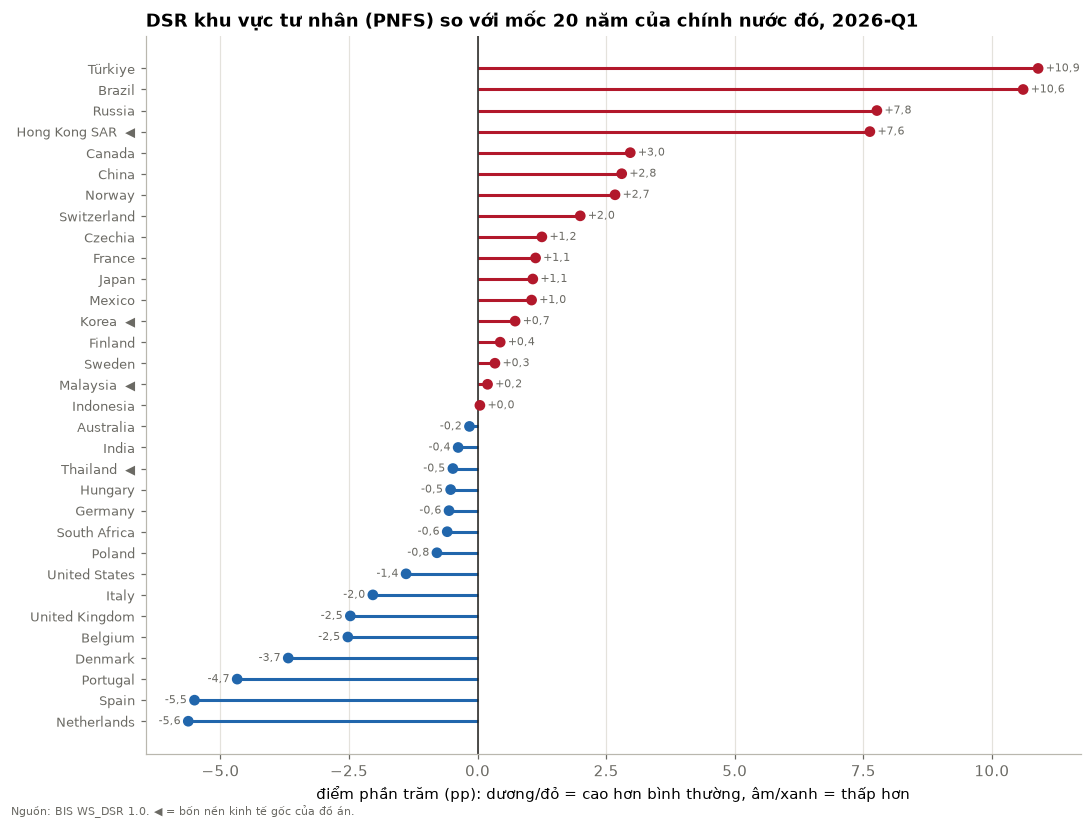

In [6]:
fig, ax = plt.subplots(figsize=(10, 7.5))
y = np.arange(len(latest))
colors = ["#b2182b" if g > 0 else "#2166ac" for g in latest.gap_now]
ax.hlines(y, 0, latest.gap_now, color=colors, lw=2)
ax.scatter(latest.gap_now, y, color=colors, s=36, zorder=3)
ax.axvline(0, color=INK, lw=1)
ax.set_yticks(y, [f"{EN[c]}{'  ◀' if c in FOCUS else ''}" for c in latest.index], fontsize=8.5)
for yy, g in zip(y, latest.gap_now):
    ax.annotate(vn(g, 1, True), (g, yy), xytext=(5 if g >= 0 else -5, 0), textcoords="offset points",
                ha="left" if g >= 0 else "right", va="center", fontsize=7.5, color=MUTED)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
q = latest.latest_q.iloc[0]
ax.set_title(f"DSR khu vực tư nhân (PNFS) so với mốc 20 năm của chính nước đó, {q}")
ax.set_xlabel("điểm phần trăm (pp): dương/đỏ = cao hơn bình thường, âm/xanh = thấp hơn")
fig.text(0.01, 0.005, "Nguồn: BIS WS_DSR 1.0. ◀ = bốn nền kinh tế gốc của đồ án.", fontsize=7.5, color=MUTED)
plt.tight_layout(); plt.show()

## ④ Mốc bắt đầu tăng lãi suất — xác định bằng thuật toán

Cho từng nền kinh tế, trên chuỗi lãi suất chính sách **tháng** trong cửa sổ 01/2021–12/2023:

1. **Đáy** = tháng sớm nhất lãi suất chạm mức thấp nhất trong cửa sổ.
2. **Mốc tăng (lift-off)** = tháng đầu tiên sau đáy (vẫn trong cửa sổ) có lãi suất cao hơn đáy.
3. **Đỉnh chu kỳ** = lãi suất cao nhất từ mốc tăng đến 12/2024; **mức tăng** = đỉnh − đáy (pp).

Không có tháng nào thoả bước 2 → **"không có chu kỳ tăng"**, loại khỏi phân tích độ trễ.

**Ánh xạ lãi suất:** các nước khu vực euro dùng lãi suất ECB (BIS `XM`) kể từ tháng 1 của năm gia nhập
euro (danh sách và năm gia nhập lấy từ trang chính thức của ECB); trước đó dùng lãi suất quốc gia nếu BIS có.
Hong Kong giữ lãi suất cơ bản HKMA nhưng được ghi chú là neo tỷ giá theo USD; Singapore điều hành bằng tỷ giá
nên không có chuỗi lãi suất chính sách.

In [7]:
cyc = R.cycles.copy()
cyc["name"] = [EN[c] for c in cyc.index]
show = cyc[["name", "policy_code", "has_cycle", "trough", "trough_date", "liftoff", "peak", "peak_date", "hike_pp", "reason"]]
print("Không có chu kỳ tăng:", {c: r for c, r in cyc.loc[~cyc.has_cycle, "reason"].items()})
print("\nGhi chú chế độ tỷ giá:")
for c, n in CTY.loc[CTY.policy_note.ne("") & ~CTY.euro_member, "policy_note"].items():
    print(f"  {c}: {n}")
show.sort_values("liftoff")

Không có chu kỳ tăng: {'CN': 'no hike after the 2021-2023 trough', 'JP': 'no hike after the 2021-2023 trough', 'SG': 'no policy-rate data in 2021-2023'}

Ghi chú chế độ tỷ giá:
  DK: Fixed exchange rate policy against the euro; Danmarks Nationalbank's rate is set to keep the krone stable, so it largely follows the ECB.
  HK: USD peg (Linked Exchange Rate System). The HKMA base rate is set by formula from the US policy rate, so Hong Kong imports the Fed cycle.
  SG: MAS conducts monetary policy through the exchange rate (S$NEER), not an interest rate; BIS WS_CBPOL has no Singapore series.


,name,policy_code,has_cycle,trough,trough_date,liftoff,peak,peak_date,hike_pp,reason
iso2,,,,,,,,,,
RU,Russia,RU,True,4.250,2021-01-31,2021-03-31,21.000,2024-10-31,16.75,
BR,Brazil,BR,True,2.000,2021-01-31,2021-03-31,13.750,2022-08-31,11.75,
DK,Denmark,DK,True,-0.600,2021-01-31,2021-03-31,3.600,2023-09-30,4.20,
IS,Iceland,IS,True,0.750,2021-01-31,2021-05-31,9.250,2023-08-31,8.50,
CZ,Czechia,CZ,True,0.250,2021-01-31,2021-06-30,7.000,2022-06-30,6.75,
MX,Mexico,MX,True,4.000,2021-02-28,2021-06-30,11.250,2023-03-31,7.25,
HU,Hungary,HU,True,0.600,2021-01-31,2021-06-30,13.000,2022-09-30,12.40,
CL,Chile,CL,True,0.500,2021-01-31,2021-07-31,11.250,2022-10-31,10.75,
PE,Peru,PE,True,0.250,2021-01-31,2021-08-31,7.750,2023-01-31,7.50,


## ⑤ Độ trễ: từ mốc tăng lãi suất đến đỉnh DSR (tính theo quý)

- **Kết quả chính dùng chuỗi PNFS (P)**; H và N chỉ là phân tích tách nhóm cho các nước có số liệu.
- Quý mốc = quý chứa tháng lift-off. Đỉnh = quý đầu tiên đạt DSR cao nhất **từ quý mốc trở đi**.
  Độ trễ = số quý giữa hai mốc. **Độ chính xác ±1 quý**: lift-off là số tháng, DSR là tỷ lệ theo quý.
- **Bị cắt cụt (censored):** đỉnh rơi đúng quan sát cuối của mẫu → đỉnh thật có thể còn ở phía sau; độ trễ
  đo được chỉ là **cận dưới**. Báo cáo chính dùng các chuỗi không bị cắt cụt; Kaplan–Meier là kiểm tra độ vững.
- **Không tăng:** DSR không vượt mức trước lift-off, hoặc đỉnh chính là quý mốc (sau đó chỉ giảm) → không có
  đỉnh truyền dẫn để đo, không đưa vào phân phối.

In [8]:
L = R.lags.copy()
L["name"] = [EN[c] for c in L.iso2]
L["status"] = np.select(
    [~L.has_cycle, L.no_rise, L.censored], ["không có chu kỳ tăng", "không tăng", "cắt cụt (cận dưới)"], "đo được")
P = L[L.borrower == "P"].sort_values(["status", "lag_q"])
P[["name", "liftoff", "liftoff_q", "base", "peak_q", "peak", "lag_q", "rise_pp", "hike_pp", "status"]].round(2)

,name,liftoff,liftoff_q,base,peak_q,peak,lag_q,rise_pp,hike_pp,status
34,India,2022-05-31,2022-06-30,10.0,2026-03-31,12.5,15.0,2.5,2.50,cắt cụt (cận dưới)
6,Brazil,2021-03-31,2021-03-31,16.6,2026-03-31,29.8,20.0,13.2,11.75,cắt cụt (cận dưới)
11,China,NaT,NaT,NaN,NaT,NaN,NaN,NaN,NaN,không có chu kỳ tăng
40,Japan,NaT,NaT,NaN,NaT,NaN,NaN,NaN,NaN,không có chu kỳ tăng
15,Germany,2022-07-31,2022-09-30,12.7,2022-09-30,12.7,0.0,0.0,4.50,không tăng
21,Spain,2022-07-31,2022-09-30,13.5,2022-09-30,13.3,0.0,-0.2,4.50,không tăng
27,France,2022-07-31,2022-09-30,20.3,2022-09-30,20.5,0.0,0.2,4.50,không tăng
30,United Kingdom,2021-12-31,2021-12-31,14.1,2021-12-31,13.9,0.0,-0.2,5.15,không tăng
48,Netherlands,2022-07-31,2022-09-30,30.1,2022-09-30,30.3,0.0,0.2,4.50,không tăng
45,Malaysia,2022-05-31,2022-06-30,15.5,2025-06-30,15.5,12.0,0.0,1.25,không tăng


In [9]:
D = R.lag_dist
def dist_line(b):
    d = D[b]; u = d["uncensored"]; a = d["all_lower_bound"]
    return (f"{b}: n={u['n']} chuỗi đo được — trung vị {u['median']:.0f} quý, IQR {u['q1']:.1f}–{u['q3']:.1f}, "
            f"khoảng {u['min']:.0f}–{u['max']:.0f} | +{d['n_censored']} cắt cụt (tính như cận dưới: trung vị "
            f"{a['median']:.1f}; Kaplan–Meier: {d['km_median']}) | không tăng: {d['n_no_rise']} | "
            f"không có chu kỳ: {d['n_no_cycle']}")
for b in "PHN":
    print(dist_line(b))

# Sensitivity: drop rises below 0.5pp (BIS publishes DSR to one decimal).
usable = L[L.has_cycle & ~L.no_rise & ~L.censored & (L.borrower == "P")]
big = usable[usable.rise_pp >= 0.5]
print(f"\nĐộ vững — chỉ giữ chuỗi P tăng ≥ 0,5pp: n={len(big)}, trung vị {big.lag_q.median():.1f} quý "
      f"(so với {D['P']['uncensored']['median']:.1f} khi giữ tất cả).")

P: n=22 chuỗi đo được — trung vị 8 quý, IQR 6.0–11.0, khoảng 1–17 | +2 cắt cụt (tính như cận dưới: trung vị 8.0; Kaplan–Meier: 8.0) | không tăng: 6 | không có chu kỳ: 2
H: n=10 chuỗi đo được — trung vị 6 quý, IQR 5.0–7.8, khoảng 3–13 | +1 cắt cụt (tính như cận dưới: trung vị 6.0; Kaplan–Meier: 6.0) | không tăng: 5 | không có chu kỳ: 1
N: n=6 chuỗi đo được — trung vị 10 quý, IQR 7.2–11.8, khoảng 2–12 | +1 cắt cụt (tính như cận dưới: trung vị 11.0; Kaplan–Meier: 11.0) | không tăng: 9 | không có chu kỳ: 1

Độ vững — chỉ giữ chuỗi P tăng ≥ 0,5pp: n=18, trung vị 8.5 quý (so với 8.0 khi giữ tất cả).


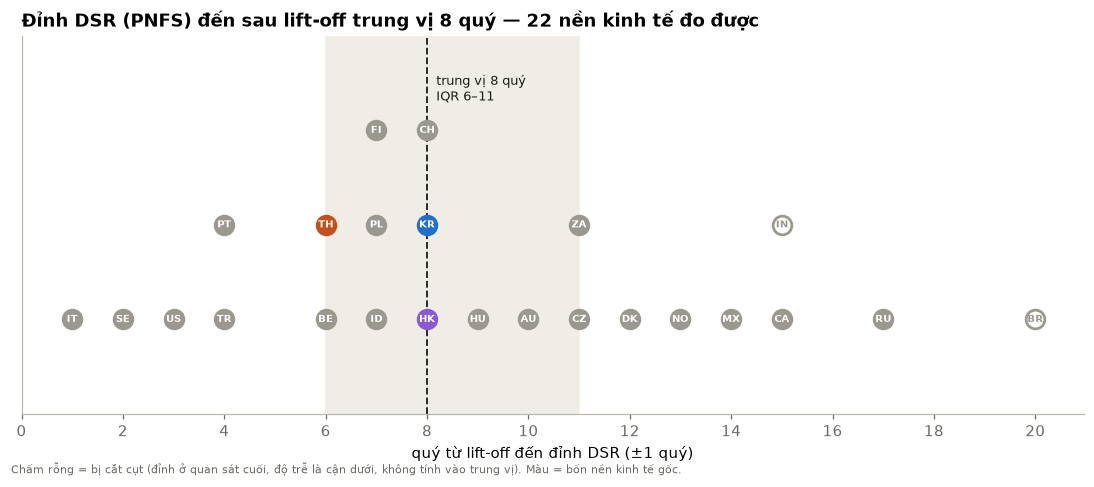

In [10]:
# Dot histogram: one dot per economy, so n is visible and nothing is hidden in a bar.
fig, ax = plt.subplots(figsize=(10, 4.4))
p_ok = L[(L.borrower == "P") & L.has_cycle & ~L.no_rise].sort_values("lag_q")
stack = {}
for _, r in p_ok.iterrows():
    k = int(r.lag_q); stack[k] = stack.get(k, 0) + 1
    col = FOCUS_COLOR.get(r.iso2, "#9a988f")
    ax.scatter(k, stack[k], s=150, color="white" if r.censored else col, edgecolor=col, lw=1.8, zorder=3)
    ax.annotate(r.iso2, (k, stack[k]), ha="center", va="center", fontsize=6.5,
                color=col if r.censored else "white", fontweight="bold", zorder=4)
u = D["P"]["uncensored"]
ax.axvspan(u["q1"], u["q3"], color="#efede6", zorder=0)
ax.axvline(u["median"], color=INK, lw=1.2, ls="--")
ax.annotate(f"trung vị {u['median']:.0f} quý\nIQR {u['q1']:.0f}–{u['q3']:.0f}", (u["median"], max(stack.values()) + 0.6),
            xytext=(6, 0), textcoords="offset points", fontsize=8.5, color=INK, va="top")
ax.set_ylim(0, max(stack.values()) + 1); ax.set_yticks([])
ax.set_xticks(range(0, int(p_ok.lag_q.max()) + 2, 2))
ax.set_xlabel("quý từ lift-off đến đỉnh DSR (±1 quý)")
ax.set_title(f"Đỉnh DSR (PNFS) đến sau lift-off trung vị {u['median']:.0f} quý — {u['n']} nền kinh tế đo được")
fig.text(0.01, 0.01, "Chấm rỗng = bị cắt cụt (đỉnh ở quan sát cuối, độ trễ là cận dưới, không tính vào trung vị). "
         "Màu = bốn nền kinh tế gốc.", fontsize=7.5, color=MUTED)
plt.tight_layout(); plt.show()

## ⑥ Liên quốc gia: tăng lãi suất nhiều hơn có đi kèm DSR tăng nhiều hơn, hay đến muộn hơn?

Chỉ các nền kinh tế có chu kỳ tăng và có đỉnh DSR đo được. Mức tăng DSR (pp) là **thay đổi trong chính chuỗi
của mỗi nước**, nên tương đương thay đổi của độ lệch so với mốc nền — so được giữa các nước.
**Đây là tương quan mô tả trên n nhỏ, không phải quan hệ nhân quả.**

mức tăng lãi suất ↔ mức tăng DSR: Pearson r = 0.91 (KTC 95% 0.79 … 0.96), Spearman ρ = 0.47, n = 24
mức tăng lãi suất ↔ độ trễ (không tính cắt cụt): Pearson r = -0.03 (KTC 95% -0.44 … 0.40), Spearman ρ = 0.26, n = 22
Độ vững — bỏ các chu kỳ tăng > 10pp ['BR', 'HU', 'RU', 'TR']: r = 0.09 (KTC 95% -0.37 … 0.51), n = 20


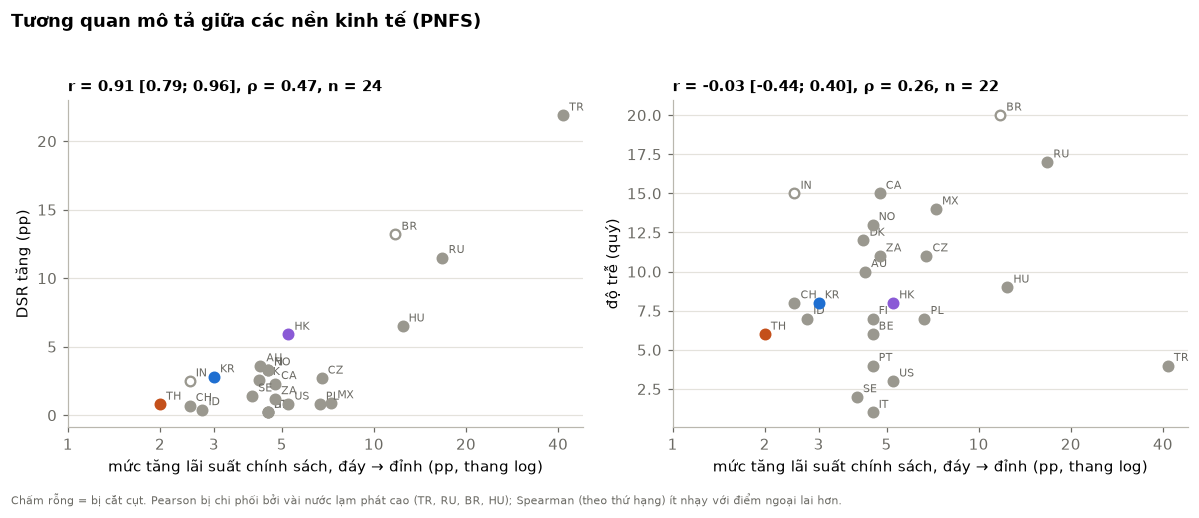

In [11]:
cx = R.cross
for k, lab in [("hike_vs_rise", "mức tăng lãi suất ↔ mức tăng DSR"), ("hike_vs_lag", "mức tăng lãi suất ↔ độ trễ (không tính cắt cụt)")]:
    c = cx[k]
    print(f"{lab}: Pearson r = {c['r']:.2f} (KTC 95% {c['lo']:.2f} … {c['hi']:.2f}), Spearman ρ = {c['spearman']:.2f}, n = {c['n']}")
s = cx["hike_vs_rise_small"]
print(f"Độ vững — bỏ các chu kỳ tăng > {s['threshold_pp']:.0f}pp {s['excluded']}: "
      f"r = {s['r']:.2f} (KTC 95% {s['lo']:.2f} … {s['hi']:.2f}), n = {s['n']}")

pp = L[(L.borrower == "P") & L.has_cycle & ~L.no_rise]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, ycol, ylab, key in [(axes[0], "rise_pp", "DSR tăng (pp)", "hike_vs_rise"),
                            (axes[1], "lag_q", "độ trễ (quý)", "hike_vs_lag")]:
    for _, r in pp.iterrows():
        col = FOCUS_COLOR.get(r.iso2, "#9a988f")
        ax.scatter(r.hike_pp, r[ycol], s=40, color="white" if r.censored else col, edgecolor=col, lw=1.5, zorder=3)
        ax.annotate(r.iso2, (r.hike_pp, r[ycol]), xytext=(4, 3), textcoords="offset points", fontsize=7, color=MUTED)
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 3, 5, 10, 20, 40], ["1", "2", "3", "5", "10", "20", "40"])
    ax.minorticks_off()
    ax.set_xlabel("mức tăng lãi suất chính sách, đáy → đỉnh (pp, thang log)")
    ax.set_ylabel(ylab)
    c = cx[key]
    ax.set_title(f"r = {c['r']:.2f} [{c['lo']:.2f}; {c['hi']:.2f}], ρ = {c['spearman']:.2f}, n = {c['n']}", fontsize=10)
fig.suptitle("Tương quan mô tả giữa các nền kinh tế (PNFS)", x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.005, "Chấm rỗng = bị cắt cụt. Pearson bị chi phối bởi vài nước lạm phát cao (TR, RU, BR, HU); "
         "Spearman (theo thứ hạng) ít nhạy với điểm ngoại lai hơn.", fontsize=7.5, color=MUTED)
plt.tight_layout(rect=(0, 0.03, 1, 0.95)); plt.show()

## ⑦ Kiểm tra chéo NPL ↔ DSR — chỉ mang tính mô tả

DSR hạ xuống tần suất năm bằng quý IV (cuối kỳ, đúng quy ước BIS) để khớp NPL năm của World Bank;
**không** nội suy NPL lên quý. Mỗi hệ số kèm **n** và **khoảng tin cậy 95% (Fisher z)**. Tương quan mức dễ bị
xu hướng chung chi phối; tương quan của **biến động năm** ít bị hơn nhưng n nhỏ hơn một.

In [12]:
N = R.npl_corr.copy()
N["name"] = [EN[c] for c in N.iso2]
N["mức: r [KTC95]"] = [f"{r:+.2f} [{lo:+.2f}; {hi:+.2f}]" if np.isfinite(lo) else f"{r:+.2f} [—]"
                       for r, lo, hi in zip(N.r_level, N.lo_level, N.hi_level)]
N["biến động: r [KTC95]"] = [f"{r:+.2f} [{lo:+.2f}; {hi:+.2f}]" if np.isfinite(lo) else "—"
                             for r, lo, hi in zip(N.r_change, N.lo_change, N.hi_change)]
sig = N[(N.lo_change > 0) | (N.hi_change < 0)]
print(f"{len(N)} nền kinh tế; KTC 95% của tương quan biến động KHÔNG chứa 0 ở {len(sig)}: {sig.iso2.tolist()}")
N[["name", "years", "n_level", "mức: r [KTC95]", "n_change", "biến động: r [KTC95]", "npl_last_year"]]

32 nền kinh tế; KTC 95% của tương quan biến động KHÔNG chứa 0 ở 1: ['NO']


,name,years,n_level,mức: r [KTC95],n_change,biến động: r [KTC95],npl_last_year
0,Australia,2006-2025,20,+0.06 [-0.39; +0.49],19,-0.33 [-0.68; +0.15],2025
1,Belgium,2006-2025,20,+0.69 [+0.35; +0.87],19,+0.29 [-0.18; +0.66],2025
2,Brazil,2005-2025,21,-0.07 [-0.49; +0.37],20,+0.24 [-0.23; +0.62],2025
3,Canada,2005-2025,21,-0.36 [-0.68; +0.09],20,+0.03 [-0.42; +0.47],2025
4,Switzerland,2005-2025,21,-0.50 [-0.77; -0.09],20,+0.07 [-0.39; +0.49],2025
5,China,2010-2024,15,+0.56 [+0.06; +0.83],14,-0.05 [-0.56; +0.50],2024
6,Czechia,2008-2025,18,-0.66 [-0.86; -0.29],17,-0.16 [-0.59; +0.35],2025
7,Germany,2022-2025,4,-0.86 [-1.00; +0.58],3,—,2025
8,Denmark,2010-2025,14,+0.76 [+0.38; +0.92],13,+0.01 [-0.55; +0.56],2025
9,Spain,2012-2025,14,+0.89 [+0.67; +0.96],13,-0.07 [-0.60; +0.50],2025


## ⑧ Bốn nền kinh tế gốc trong bức tranh toàn cầu

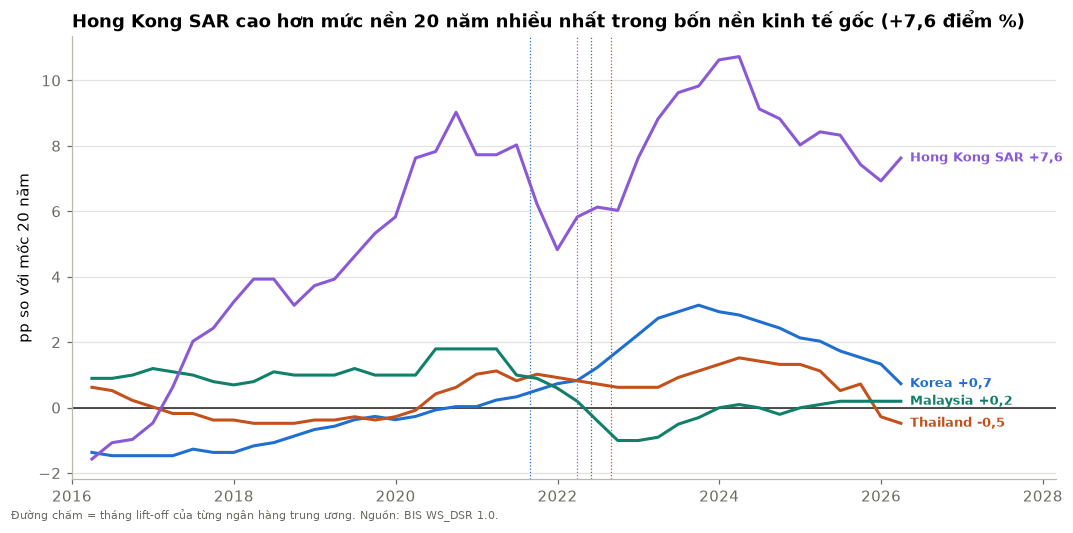

,name,borrower,liftoff,peak_q,lag_q,rise_pp,status,gap_now,unwound_%
31,Hong Kong SAR,P,2022-03-31,2024-03-31,8.0,5.9,đo được,7.63,28.90
41,Korea,H,2021-08-31,2024-09-30,12.0,0.6,đo được,0.47,63.12
42,Korea,N,2021-08-31,2023-09-30,8.0,7.8,đo được,-0.68,109.95
43,Korea,P,2021-08-31,2023-09-30,8.0,2.8,đo được,0.73,76.68
45,Malaysia,P,2022-05-31,2025-06-30,12.0,0.0,không tăng,0.19,NaN
60,Thailand,P,2022-08-31,2024-03-31,6.0,0.8,đo được,-0.48,131.58


In [13]:
fig, ax = plt.subplots(figsize=(10, 4.8))
gap = R.gap.loc["2016-01-01":]
ax.axhline(0, color=INK, lw=1)
for c in FOCUS:
    s = gap[f"{c}_P"].dropna()
    ax.plot(s.index, s.values, color=FOCUS_COLOR[c], lw=2)
    ax.annotate(f"{EN[c]} {vn(s.iloc[-1], 1, True)}", (s.index[-1], s.iloc[-1]), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=8.5, color=FOCUS_COLOR[c], fontweight="bold")
    lo = R.cycles.loc[c, "liftoff"]
    ax.axvline(lo, color=FOCUS_COLOR[c], lw=0.8, ls=":")
ax.set_xlim(pd.Timestamp("2016-01-01"), gap.index.max() + pd.Timedelta(days=700))
ax.set_ylabel("pp so với mốc 20 năm")
top = max(FOCUS, key=lambda c: gap[f"{c}_P"].dropna().iloc[-1])
ax.set_title(f"{EN[top]} cao hơn mức nền 20 năm nhiều nhất trong bốn nền kinh tế gốc "
             f"({vn(gap[f'{top}_P'].dropna().iloc[-1], 1, True)} điểm %)")
fig.text(0.01, 0.005, "Đường chấm = tháng lift-off của từng ngân hàng trung ương. Nguồn: BIS WS_DSR 1.0.", fontsize=7.5, color=MUTED)
plt.tight_layout(); plt.show()

F = L[L.iso2.isin(FOCUS)][["name", "borrower", "liftoff", "peak_q", "lag_q", "rise_pp", "status"]]
REC = R.recovery.set_index("series")
F["gap_now"] = [REC.loc[s, "gap_now"] for s in L[L.iso2.isin(FOCUS)].series]
F["unwound_%"] = [REC.loc[s, "unwound_pct"] for s in L[L.iso2.isin(FOCUS)].series]
F.round(2)

---
# Câu chuyện dữ liệu

*Các đoạn dưới đây được sinh từ kết quả vừa tính ở trên — chạy lại notebook với dữ liệu mới thì chữ và số tự
khớp. Không đoạn nào ngoại suy ra ngoài kỳ dữ liệu cuối cùng.*

In [14]:
u = D["P"]["uncensored"]
n_cycle = int((P.has_cycle).sum()); n_dsr = len(P)
rec_p = R.recovery[R.recovery.borrower == "P"].set_index("iso2")
q_last = rec_p.latest_q.max()
above = rec_p[rec_p.gap_now > 0].sort_values("gap_now", ascending=False)
hk, kr, th, my = (P.set_index("iso2").loc[c] for c in ["HK", "KR", "TH", "MY"])
kh, kn = (L.set_index("series").loc[s] for s in ["KR_H", "KR_N"])
cens = P[P.status == "cắt cụt (cận dưới)"].iso2.tolist()
nocyc = P[~P.has_cycle].iso2.tolist()
norise = P[P.status == "không tăng"].iso2.tolist()

sm = cx["hike_vs_rise_small"]
measured = [c for c in FOCUS if P.set_index("iso2").loc[c, "status"] == "đo được"]
inside = [c for c in measured if u["q1"] <= P.set_index("iso2").loc[c, "lag_q"] <= u["q3"]]
focus_iqr_sentence = (
    f"{len(inside)}/{len(measured)} nước gốc có đỉnh đo được nằm trong khoảng tứ phân vị toàn cầu "
    f"({', '.join(EN[c] for c in inside) or 'không nước nào'})"
    + (": về **thời gian**, bốn nước gốc không phải ngoại lệ; khác biệt nằm ở **độ lớn** của cú sốc và của gánh nặng."
       if len(inside) == len(measured) else ".")
)

display(Markdown(f"""
### 1. Mở đầu
Trong {n_dsr} nền kinh tế BIS công bố DSR, {n_cycle} trải qua một chu kỳ tăng lãi suất bắt đầu trong
2021–2023. Ở quý dữ liệu gần nhất ({q_last}), **{len(above)}/{len(rec_p)}** nền kinh tế vẫn có DSR khu vực tư nhân
cao hơn mức trung bình 20 năm của chính mình; cao nhất là {", ".join(f"{EN[c]} ({vn(g, 1, True)}pp)" for c, g in above.gap_now.head(4).items())}.
Hong Kong — một trong bốn nền kinh tế gốc của đồ án — vẫn cao hơn mức nền **{vn(rec_p.loc['HK','gap_now'], 1)} điểm %**.

### 2. Độ trễ điển hình: {u['median']:.0f} quý (≈ {u['median'] * 3:.0f} tháng ± 3 tháng), so với giả thuyết 12–18 tháng ban đầu
Tính từ quý ngân hàng trung ương bắt đầu tăng lãi suất đến quý DSR đạt đỉnh, trung vị là **{u['median']:.0f} quý**
(khoảng tứ phân vị {u['q1']:.0f}–{u['q3']:.0f} quý, n = {u['n']} nền kinh tế, độ chính xác ±1 quý). {len(cens)} chuỗi bị
cắt cụt ({", ".join(EN[c] for c in cens)}): đỉnh rơi vào quý cuối của mẫu nên độ trễ thật ít nhất bằng con số đo được.
{", ".join(EN[c] for c in nocyc)} không có chu kỳ tăng trong cửa sổ này; ở {", ".join(EN[c] for c in norise)},
DSR không vượt mức trước khi tăng lãi suất nên không có đỉnh để đo.

### 3. Bốn nền kinh tế gốc nằm ở đâu trong phân phối
- **Hong Kong**: lift-off {hk.liftoff:%m/%Y} (neo tỷ giá theo USD; Fed: {R.cycles.loc['US', 'liftoff']:%m/%Y}), đỉnh {core.qlabel(hk.peak_q)},
  trễ **{hk.lag_q:.0f} quý**, DSR tăng {vn(hk.rise_pp)}pp sau mức tăng lãi suất {vn(hk.hike_pp, 2)}pp.
- **Hàn Quốc**: lift-off sớm ({kr.liftoff:%m/%Y}), PNFS trễ **{kr.lag_q:.0f} quý**; tách nhóm: doanh nghiệp đạt đỉnh sau
  {kn.lag_q:.0f} quý (+{vn(kn.rise_pp)}pp), hộ gia đình sau {kh.lag_q:.0f} quý (+{vn(kh.rise_pp)}pp).
- **Thái Lan**: trễ **{th.lag_q:.0f} quý**, DSR chỉ tăng {vn(th.rise_pp)}pp với mức tăng lãi suất {vn(th.hike_pp, 2)}pp.
- **Malaysia**: lãi suất tăng {vn(my.hike_pp, 2)}pp; trạng thái độ trễ: **{my.status}**{" — DSR không vượt mức trước lift-off nên không có đỉnh truyền dẫn để đo" if my.status == "không tăng" else f", {my.lag_q:.0f} quý"}.

{focus_iqr_sentence}

### 4. {"Tương quan giữa mức tăng lãi suất và mức tăng DSR đến từ vài chu kỳ tăng cực lớn" if (sm['lo'] <= 0 <= sm['hi']) else "Mức tăng lãi suất lớn hơn đi cùng mức tăng DSR lớn hơn, kể cả khi bỏ các chu kỳ cực lớn"}
Giữa các nền kinh tế, mức tăng lãi suất có tương quan với mức tăng DSR (Pearson r = {vn(cx['hike_vs_rise']['r'], 2)},
KTC 95% {vn(cx['hike_vs_rise']['lo'], 2)} … {vn(cx['hike_vs_rise']['hi'], 2)}, n = {cx['hike_vs_rise']['n']}), nhưng tương quan
theo thứ hạng yếu hơn nhiều (Spearman ρ = {vn(cx['hike_vs_rise']['spearman'], 2)}). Bỏ {len(sm['excluded'])} chu kỳ tăng trên
{sm['threshold_pp']:.0f}pp ({", ".join(EN[c] for c in sm['excluded'])}) thì r còn {vn(sm['r'], 2)} (KTC 95% {vn(sm['lo'], 2)} … {vn(sm['hi'], 2)},
n = {sm['n']}). Với độ trễ, quan hệ không rõ (r = {vn(cx['hike_vs_lag']['r'], 2)}, KTC 95% {vn(cx['hike_vs_lag']['lo'], 2)} …
{vn(cx['hike_vs_lag']['hi'], 2)}, n = {cx['hike_vs_lag']['n']}).
Đây là tương quan mô tả, không phải nhân quả.

### 5. Nợ xấu không đi theo DSR một cách nhất quán
Trên {len(N)} nền kinh tế có cả DSR và NPL, khoảng tin cậy 95% của tương quan biến động năm chứa 0 ở
{len(N) - len(sig)} nước. Với n từ {N.n_change.min()} đến {N.n_change.max()} năm, các hệ số này chỉ mang tính mô tả.

### 6. Giới hạn
Độ trễ đo bằng một đỉnh duy nhất trên chuỗi quý (±1 quý); DSR của BIS dựa trên giả định kỳ hạn cố định;
chỉ {n_hn} nền kinh tế có tách hộ gia đình/doanh nghiệp; NPL là số năm và có nước chưa cập nhật năm gần nhất.
Không có phần nào của phân tích dự báo sau {q_last}.
"""))


### 1. Mở đầu
Trong 32 nền kinh tế BIS công bố DSR, 30 trải qua một chu kỳ tăng lãi suất bắt đầu trong
2021–2023. Ở quý dữ liệu gần nhất (2026-Q1), **17/32** nền kinh tế vẫn có DSR khu vực tư nhân
cao hơn mức trung bình 20 năm của chính mình; cao nhất là Türkiye (+10,9pp), Brazil (+10,6pp), Russia (+7,8pp), Hong Kong SAR (+7,6pp).
Hong Kong — một trong bốn nền kinh tế gốc của đồ án — vẫn cao hơn mức nền **7,6 điểm %**.

### 2. Độ trễ điển hình: 8 quý (≈ 24 tháng ± 3 tháng), so với giả thuyết 12–18 tháng ban đầu
Tính từ quý ngân hàng trung ương bắt đầu tăng lãi suất đến quý DSR đạt đỉnh, trung vị là **8 quý**
(khoảng tứ phân vị 6–11 quý, n = 22 nền kinh tế, độ chính xác ±1 quý). 2 chuỗi bị
cắt cụt (India, Brazil): đỉnh rơi vào quý cuối của mẫu nên độ trễ thật ít nhất bằng con số đo được.
China, Japan không có chu kỳ tăng trong cửa sổ này; ở Germany, Spain, France, United Kingdom, Netherlands, Malaysia,
DSR không vượt mức trước khi tăng lãi suất nên không có đỉnh để đo.

### 3. Bốn nền kinh tế gốc nằm ở đâu trong phân phối
- **Hong Kong**: lift-off 03/2022 (neo tỷ giá theo USD; Fed: 03/2022), đỉnh 2024-Q1,
  trễ **8 quý**, DSR tăng 5,9pp sau mức tăng lãi suất 5,25pp.
- **Hàn Quốc**: lift-off sớm (08/2021), PNFS trễ **8 quý**; tách nhóm: doanh nghiệp đạt đỉnh sau
  8 quý (+7,8pp), hộ gia đình sau 12 quý (+0,6pp).
- **Thái Lan**: trễ **6 quý**, DSR chỉ tăng 0,8pp với mức tăng lãi suất 2,00pp.
- **Malaysia**: lãi suất tăng 1,25pp; trạng thái độ trễ: **không tăng** — DSR không vượt mức trước lift-off nên không có đỉnh truyền dẫn để đo.

3/3 nước gốc có đỉnh đo được nằm trong khoảng tứ phân vị toàn cầu (Korea, Thailand, Hong Kong SAR): về **thời gian**, bốn nước gốc không phải ngoại lệ; khác biệt nằm ở **độ lớn** của cú sốc và của gánh nặng.

### 4. Tương quan giữa mức tăng lãi suất và mức tăng DSR đến từ vài chu kỳ tăng cực lớn
Giữa các nền kinh tế, mức tăng lãi suất có tương quan với mức tăng DSR (Pearson r = 0,91,
KTC 95% 0,79 … 0,96, n = 24), nhưng tương quan
theo thứ hạng yếu hơn nhiều (Spearman ρ = 0,47). Bỏ 4 chu kỳ tăng trên
10pp (Brazil, Hungary, Russia, Türkiye) thì r còn 0,09 (KTC 95% -0,37 … 0,51,
n = 20). Với độ trễ, quan hệ không rõ (r = -0,03, KTC 95% -0,44 …
0,40, n = 22).
Đây là tương quan mô tả, không phải nhân quả.

### 5. Nợ xấu không đi theo DSR một cách nhất quán
Trên 32 nền kinh tế có cả DSR và NPL, khoảng tin cậy 95% của tương quan biến động năm chứa 0 ở
31 nước. Với n từ 3 đến 20 năm, các hệ số này chỉ mang tính mô tả.

### 6. Giới hạn
Độ trễ đo bằng một đỉnh duy nhất trên chuỗi quý (±1 quý); DSR của BIS dựa trên giả định kỳ hạn cố định;
chỉ 17 nền kinh tế có tách hộ gia đình/doanh nghiệp; NPL là số năm và có nước chưa cập nhật năm gần nhất.
Không có phần nào của phân tích dự báo sau 2026-Q1.


## ⑨ Lưu bảng đã xử lý

In [15]:
# data/processed/ is regenerated on every run; nothing in it is edited by hand.
for f in PROC.glob("*.csv"):
    f.unlink()
T["dsr"].to_csv(PROC / "dsr_wide.csv")
R.gap.to_csv(PROC / "dsr_gap_vs_20y.csv")
R.bench.to_csv(PROC / "dsr_benchmark_20y.csv")
T["credit"].to_csv(PROC / "credit_gdp_wide.csv")
T["policy"].to_csv(PROC / "policy_rate_mapped_wide.csv")
T["npl"].to_csv(PROC / "npl_wide.csv")
R.cycles.to_csv(PROC / "policy_cycles.csv")
R.lags.to_csv(PROC / "lags.csv", index=False)
R.npl_corr.to_csv(PROC / "npl_dsr_corr.csv", index=False)
R.recovery.to_csv(PROC / "recovery.csv", index=False)
print(sorted(p.name for p in PROC.glob("*.csv")))

['credit_gdp_wide.csv', 'dsr_benchmark_20y.csv', 'dsr_gap_vs_20y.csv', 'dsr_wide.csv', 'lags.csv', 'npl_dsr_corr.csv', 'npl_wide.csv', 'policy_cycles.csv', 'policy_rate_mapped_wide.csv', 'recovery.csv']
